In [1]:
import openpyxl
print(openpyxl.__version__)

3.1.5


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
file_path = r"D:\E-commerce Return Rate Reduction Analysis\ecommerce_customer_data_custom_ratios.xlsx"

df = pd.read_excel(file_path)

In [5]:
data = df.to_numpy()

In [6]:
columns = df.columns.tolist()

print("Columns in Dataset:")
print(columns)

Columns in Dataset:
['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']


In [7]:
category = df["Product Category"].to_numpy()
returns = df["Returns"].to_numpy()

In [9]:
return_status = np.array([
    1 if str(x).lower() in ['yes', 'returned', 'true', '1']
    else 0
    for x in returns
])


In [10]:
overall_return_rate = np.mean(return_status) * 100

print("\nOverall Return Rate = {:.2f}%".format(overall_return_rate))


Overall Return Rate = 0.00%


In [11]:
unique_categories = np.unique(category)

print("\nReturn Rate by Product Category")

category_names = []
category_rates = []

for cat in unique_categories:

    index = np.where(category == cat)

    total_products = len(index[0])

    returned_products = np.sum(return_status[index])

    rate = (returned_products / total_products) * 100

    category_names.append(cat)
    category_rates.append(rate)

    print(f"{cat:15} : {rate:.2f}%")


Return Rate by Product Category
Books           : 0.00%
Clothing        : 0.00%
Electronics     : 0.00%
Home            : 0.00%


In [12]:
max_index = np.argmax(category_rates)

print("\nCategory with Highest Return Rate")
print("---------------------------------")
print("Category :", category_names[max_index])
print("Return Rate : {:.2f}%".format(category_rates[max_index]))


Category with Highest Return Rate
---------------------------------
Category : Books
Return Rate : 0.00%


In [13]:
print("\nTotal Orders :", len(return_status))
print("Returned Orders :", np.sum(return_status))
print("Non Returned Orders :", len(return_status)-np.sum(return_status))



Total Orders : 250000
Returned Orders : 0
Non Returned Orders : 250000


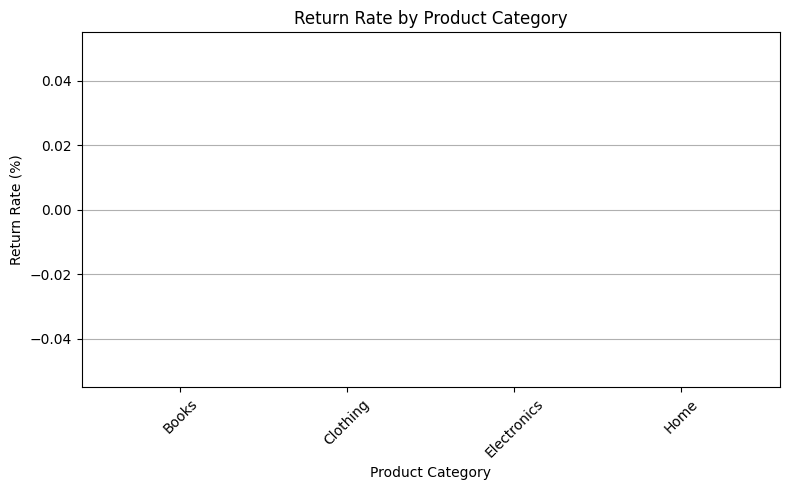

In [14]:
plt.figure(figsize=(8,5))
plt.bar(category_names, category_rates)

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

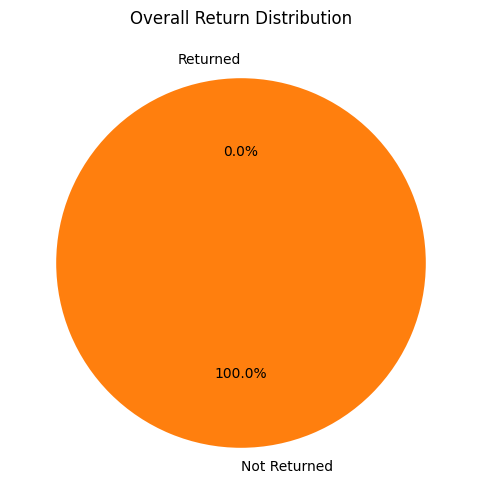

In [15]:
returned = np.sum(return_status)
not_returned = len(return_status) - returned

plt.figure(figsize=(6,6))
plt.pie(
    [returned, not_returned],
    labels=["Returned", "Not Returned"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Return Distribution")
plt.show()